6CS012 — Final Portfolio Project
Part 3: Text Classification with RNN / LSTM
Spam vs Ham SMS Detection

Student Name: Samyek Mani Tuladhar 

Student ID: 2408449

Module: 6CS012 – Artificial Intelligence and Machine Learning 

Dataset: spamvsham.csv


1. Setup and Imports

In [24]:
import os
import re
import time
import warnings
warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from wordcloud import WordCloud
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, classification_report, confusion_matrix
)
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, callbacks
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from gensim.models import Word2Vec

# Reproducibility
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)
print('TensorFlow version:', tf.__version__)

TensorFlow version: 2.10.0


2. Configuration

In [25]:

DATA_PATH = r'spamvsham.csv'

# Hyperparameters
TEST_SIZE   = 0.20    # 80/20 split
VAL_SPLIT   = 0.10    # 10% of training for validation
EPOCHS      = 20
BATCH_SIZE  = 32
EMBED_DIM   = 64 
EMBED_DIM_W2V = 100 
W2V_WINDOW  = 5
W2V_MINCOUNT = 2

print('Configuration set')
print(f'Dataset path : {DATA_PATH}')
print(f'File exists  : {os.path.exists(DATA_PATH)}')

Configuration set
Dataset path : spamvsham.csv
File exists  : True


3. Dataset Loading and Exploration


In [26]:
df = pd.read_csv(DATA_PATH, encoding='latin-1')
df = df[['v1', 'v2']].copy()
df.columns = ['label', 'text']
df['label_enc'] = (df['label'] == 'spam').astype(int)  # ham=0, spam=1
df = df.dropna(subset=['text']).reset_index(drop=True)

print(f'Dataset shape      : {df.shape}')
print(f'Null values        : {df.isnull().sum().sum()}')
print(f'\nClass distribution:')
print(df['label'].value_counts())
print(f'\nClass proportions:')
print(df['label'].value_counts(normalize=True).round(4))
df.head()

Dataset shape      : (5572, 3)
Null values        : 0

Class distribution:
label
ham     4825
spam     747
Name: count, dtype: int64

Class proportions:
label
ham     0.8659
spam    0.1341
Name: proportion, dtype: float64


,label,text,label_enc
0,ham,"Go until jurong point, crazy.. Available only ...",0
1,ham,Ok lar... Joking wif u oni...,0
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,1
3,ham,U dun say so early hor... U c already then say...,0
4,ham,"Nah I don't think he goes to usf, he lives aro...",0


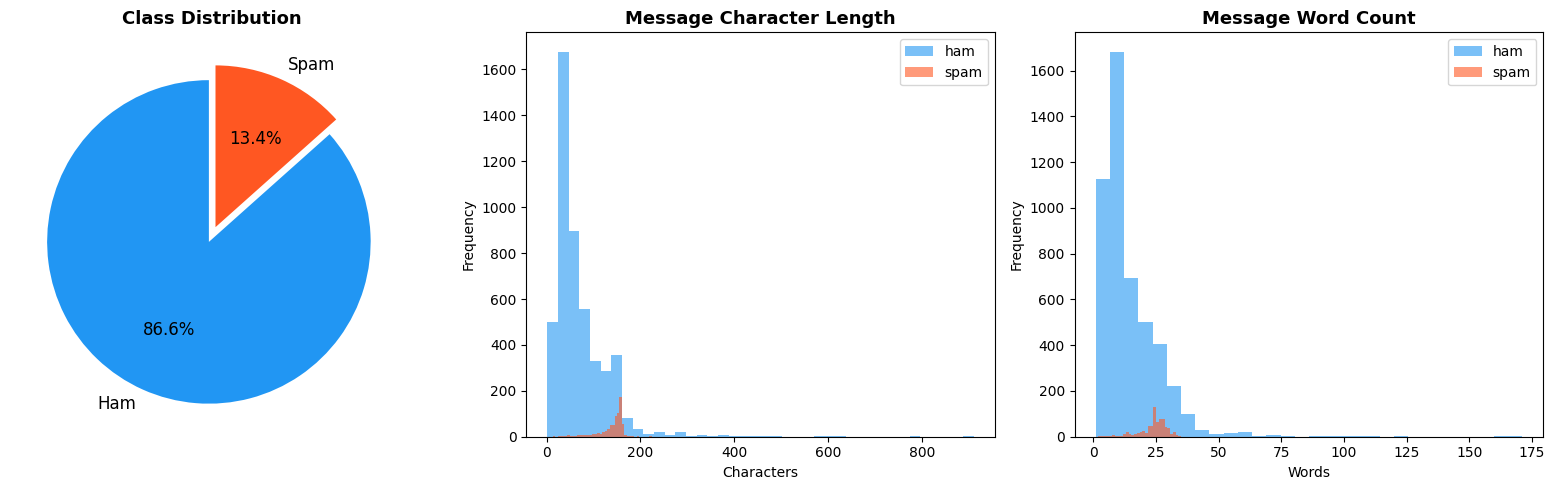

Avg words - Ham : 14.2
Avg words - Spam: 23.9


In [27]:
# analysis
df['char_len']   = df['text'].apply(len)
df['word_count'] = df['text'].apply(lambda x: len(x.split()))

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Pie chart
counts = df['label'].value_counts()
axes[0].pie(counts, labels=['Ham', 'Spam'], autopct='%1.1f%%',
            colors=['#2196F3', '#FF5722'], explode=(0.05, 0.05),
            startangle=90, textprops={'fontsize': 12})
axes[0].set_title('Class Distribution', fontsize=13, fontweight='bold')

# length distribution
for lbl, col in [('ham', '#2196F3'), ('spam', '#FF5722')]:
    subset = df[df['label'] == lbl]['char_len']
    axes[1].hist(subset, bins=40, alpha=0.6, color=col, label=lbl)
axes[1].set_title('Message Character Length', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Characters')
axes[1].set_ylabel('Frequency')
axes[1].legend()

# count distribution
for lbl, col in [('ham', '#2196F3'), ('spam', '#FF5722')]:
    subset = df[df['label'] == lbl]['word_count']
    axes[2].hist(subset, bins=30, alpha=0.6, color=col, label=lbl)
axes[2].set_title('Message Word Count', fontsize=13, fontweight='bold')
axes[2].set_xlabel('Words')
axes[2].set_ylabel('Frequency')
axes[2].legend()

plt.tight_layout()
plt.savefig('dataset_overview.png', dpi=150)
plt.show()

print(f"Avg words - Ham : {df[df['label']=='ham']['word_count'].mean():.1f}")
print(f"Avg words - Spam: {df[df['label']=='spam']['word_count'].mean():.1f}")

 Title 4. Text Preprocessing --




1. Lowercase
2. Expand contractions - arent = are not
3. Remove URLs, mentions, hashtags, numbers, special characters
4. Remove stopwords
5. Lemmatize words to their base form

In [29]:
CONTRACTIONS = {
    "ain't": 'am not', "aren't": 'are not', "can't": 'cannot',
    "couldn't": 'could not', "didn't": 'did not', "doesn't": 'does not',
    "don't": 'do not', "hadn't": 'had not', "hasn't": 'has not',
    "haven't": 'have not', "he's": 'he is', "i'm": 'i am',
    "i've": 'i have', "i'll": 'i will', "i'd": 'i would',
    "isn't": 'is not', "it's": 'it is', "let's": 'let us',
    "mustn't": 'must not', "she's": 'she is', "shouldn't": 'should not',
    "that's": 'that is', "there's": 'there is', "they're": 'they are',
    "wasn't": 'was not', "we're": 'we are', "weren't": 'were not',
    "what's": 'what is', "won't": 'will not', "wouldn't": 'would not',
    "you'd": 'you would', "you'll": 'you will', "you're": 'you are',
    "you've": 'you have'
}

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def clean_text(text): # (remove)
    text = str(text).lower()
    # contractions
    for contraction, expansion in CONTRACTIONS.items():
        text = text.replace(contraction, expansion)
    # URLs
    text = re.sub(r'http\S+|www\S+', '', text)
    # mentions and hashtags
    text = re.sub(r'@\w+|#\w+', '', text)
    # numbers
    text = re.sub(r'\d+', '', text)
    # special characters
    text = re.sub(r'[^a-z\s]', '', text)
    # Tokenize, remove stopwords, lemmatize
    tokens = text.split()
    tokens = [lemmatizer.lemmatize(w) for w in tokens if w not in stop_words and len(w) > 1]
    return ' '.join(tokens)

df['clean_text'] = df['text'].apply(clean_text)

for i in range(3):
    print(f'\nOriginal : {df["text"].iloc[i][:80]}')
    print(f'Cleaned  : {df["clean_text"].iloc[i][:80]}')


Original : Go until jurong point, crazy.. Available only in bugis n great world la e buffet
Cleaned  : go jurong point crazy available bugis great world la buffet cine got amore wat

Original : Ok lar... Joking wif u oni...
Cleaned  : ok lar joking wif oni

Original : Free entry in 2 a wkly comp to win FA Cup final tkts 21st May 2005. Text FA to 8
Cleaned  : free entry wkly comp win fa cup final tkts st may text fa receive entry question


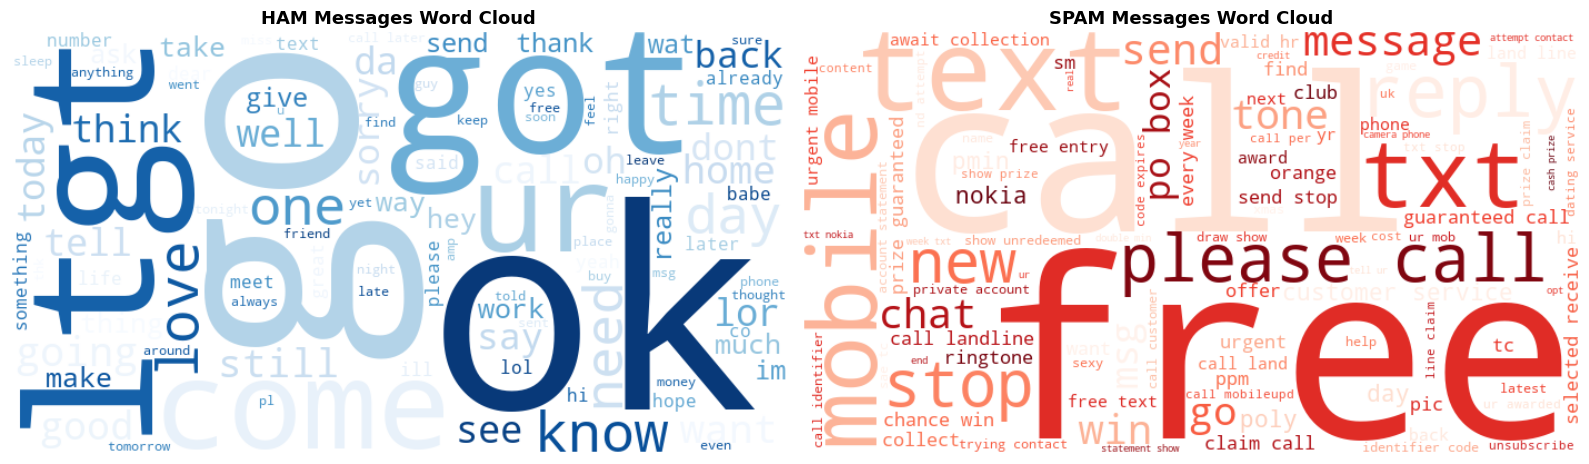

In [11]:
# Word Cloud visualization
ham_text  = ' '.join(df[df['label'] == 'ham']['clean_text'])
spam_text = ' '.join(df[df['label'] == 'spam']['clean_text'])

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for ax, txt, title, cmap in [
    (axes[0], ham_text,  'HAM Messages Word Cloud',  'Blues'),
    (axes[1], spam_text, 'SPAM Messages Word Cloud', 'Reds'),
]:
    wc = WordCloud(width=700, height=380, background_color='white',
                   colormap=cmap, max_words=100).generate(txt)
    ax.imshow(wc, interpolation='bilinear')
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.axis('off')

plt.tight_layout()
plt.savefig('wordclouds.png', dpi=150)
plt.show()

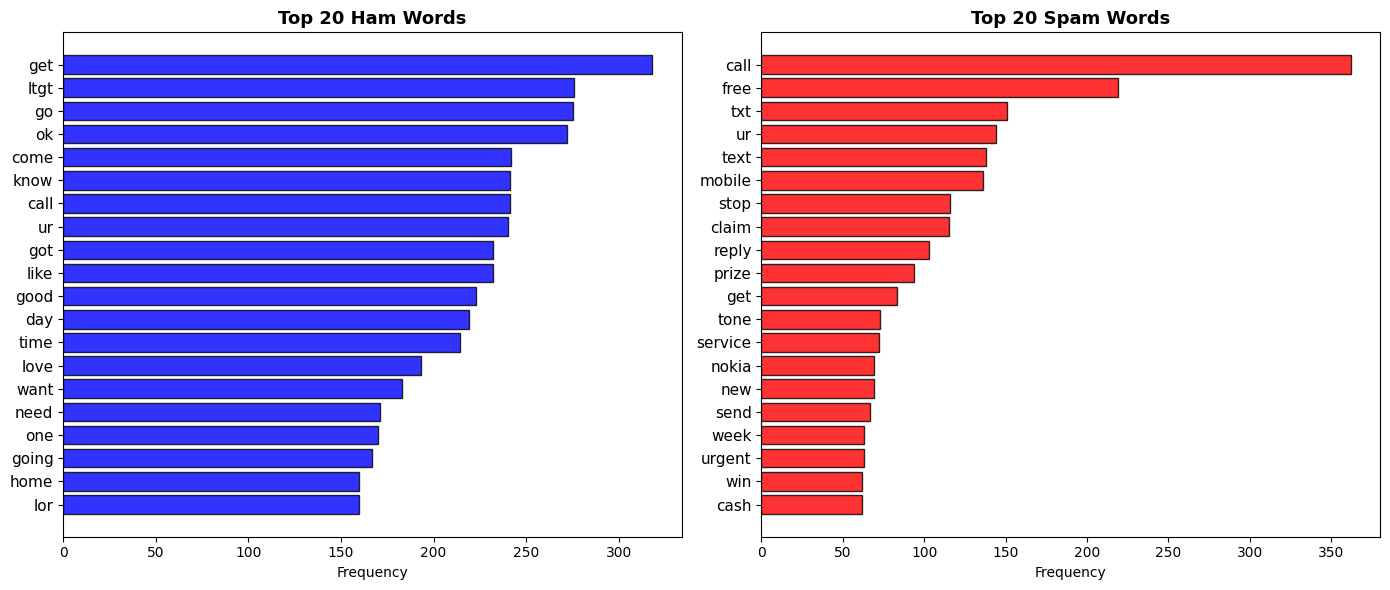

In [32]:
# 20 most frequent words per class
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

for ax, label_str, color, title in [
    (ax1, 'ham',  'blue', 'Top 20 Ham Words'),
    (ax2, 'spam', 'red', 'Top 20 Spam Words'),
]:
    words_list = ' '.join(df[df['label'] == label_str]['clean_text']).split()
    top_words  = Counter(words_list).most_common(20)
    words, freqs = zip(*top_words)
    ax.barh(range(len(words)), freqs, color=color, alpha=0.8, edgecolor='black')
    ax.set_yticks(range(len(words)))
    ax.set_yticklabels(words, fontsize=11)
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_xlabel('Frequency')
    ax.invert_yaxis()

plt.tight_layout()
plt.savefig('top_words.png', dpi=150)
plt.show()

5. Train / Test Split and Tokenization

In [33]:
# 80/20 train/test split with stratification
X = df['clean_text'].values
y = df['label_enc'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, stratify=y, random_state=SEED
)

print(f'Training samples : {len(X_train)} (spam: {y_train.sum()})')
print(f'Test samples     : {len(X_test)}  (spam: {y_test.sum()})')
print(f'Train spam ratio : {y_train.mean()*100:.1f}%')
print(f'Test  spam ratio : {y_test.mean()*100:.1f}%  (stratification confirmed)')

Training samples : 4457 (spam: 598)
Test samples     : 1115  (spam: 149)
Train spam ratio : 13.4%
Test  spam ratio : 13.4%  (stratification confirmed)


In [34]:
# Tokenization on training data only
tokenizer = Tokenizer(oov_token='<OOV>')
tokenizer.fit_on_texts(X_train)
vocab_size = len(tokenizer.word_index)

train_seqs = tokenizer.texts_to_sequences(X_train)
test_seqs  = tokenizer.texts_to_sequences(X_test)

# Use 95th percentile for MAX_LEN to avoid overly long sequences
lengths = [len(s) for s in train_seqs]
MAX_LEN = int(np.percentile(lengths, 95))

print(f'Vocabulary size : {vocab_size}')
print(f'Min seq length  : {np.min(lengths)}')
print(f'Mean seq length : {np.mean(lengths):.1f}')
print(f'Max seq length  : {np.max(lengths)}')
print(f'MAX_LEN (95th%) : {MAX_LEN}')

Vocabulary size : 6910
Min seq length  : 0
Mean seq length : 8.3
Max seq length  : 79
MAX_LEN (95th%) : 18


In [35]:
# padding
X_train_pad = pad_sequences(train_seqs, maxlen=MAX_LEN, padding='post', truncating='post')
X_test_pad  = pad_sequences(test_seqs,  maxlen=MAX_LEN, padding='post', truncating='post')

print(f'X_train shape : {X_train_pad.shape}')
print(f'X_test  shape : {X_test_pad.shape}')

X_train shape : (4457, 18)
X_test  shape : (1115, 18)


6. Word2Vec Embeddings 

In [36]:
# train Word2Vec on training
train_sentences = [text.split() for text in X_train]

print(f'Training Word2Vec on {len(train_sentences)} sentences')
w2v_model = Word2Vec(
    sentences=train_sentences,
    vector_size=EMBED_DIM_W2V,
    window=W2V_WINDOW,
    min_count=W2V_MINCOUNT,
    workers=4,
    seed=SEED,
    epochs=15
)
print(f'Word2Vec vocabulary size: {len(w2v_model.wv)}')

# embedding matrix aligned with Keras tokenizer
embedding_matrix = np.zeros((vocab_size + 1, EMBED_DIM_W2V))
covered, missing = 0, 0
for word, idx in tokenizer.word_index.items():
    if word in w2v_model.wv:
        embedding_matrix[idx] = w2v_model.wv[word]
        covered += 1
    else:
        missing += 1

print(f'Words covered by W2V : {covered}')
print(f'Words missing in W2V : {missing}')
print(f'Coverage             : {covered/(covered+missing)*100:.1f}%')
print(f'Embedding matrix shape: {embedding_matrix.shape}')

Training Word2Vec on 4457 sentences
Word2Vec vocabulary size: 3108
Words covered by W2V : 3108
Words missing in W2V : 3802
Coverage             : 45.0%
Embedding matrix shape: (6911, 100)


7. Callbacks

In [37]:
def get_callbacks(name):
    return [
        callbacks.EarlyStopping(
            monitor='val_loss', patience=4,
            restore_best_weights=True, verbose=1
        ),
        callbacks.ReduceLROnPlateau(
            monitor='val_loss', factor=0.5,
            patience=2, min_lr=1e-6, verbose=0
        ),
    ]

all_histories = {}
all_times     = {}
print('Callbacks ready.')

Callbacks ready.


8. Model 1 — Simple RNN with Trainable Embedding

In [38]:
model1 = models.Sequential([
    layers.Embedding(
        input_dim=vocab_size + 1,
        output_dim=EMBED_DIM,
        input_length=MAX_LEN,
        trainable=True,
        name='embedding'
    ),
    layers.SimpleRNN(64, dropout=0.3, name='simple_rnn'),
    layers.Dense(1, activation='sigmoid', name='output'),
], name='Model1_SimpleRNN')

model1.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)
model1.summary()

Model: "Model1_SimpleRNN"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 embedding (Embedding)       (None, 18, 64)            442304    
                                                                 
 simple_rnn (SimpleRNN)      (None, 64)                8256      
                                                                 
 output (Dense)              (None, 1)                 65        
                                                                 
Total params: 450,625
Trainable params: 450,625
Non-trainable params: 0
_________________________________________________________________


In [39]:
print('Training Model 1 - Simple RNN')
t0 = time.time()

history1 = model1.fit(
    X_train_pad, y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_split=VAL_SPLIT,
    callbacks=get_callbacks('rnn'),
    verbose=1
)

all_times['Model1_SimpleRNN']     = time.time() - t0
all_histories['Model1_SimpleRNN'] = history1
print(f'Training time : {all_times["Model1_SimpleRNN"]:.1f}s')
print(f'Best val acc  : {max(history1.history["val_accuracy"]):.4f}')

Training Model 1 - Simple RNN
Epoch 1/20
126/126 [==============================] - 4s 28ms/step - loss: 0.2094 - accuracy: 0.9312 - val_loss: 0.1264 - val_accuracy: 0.9619 - lr: 0.0010
Epoch 2/20
126/126 [==============================] - 3s 28ms/step - loss: 0.0528 - accuracy: 0.9858 - val_loss: 0.1121 - val_accuracy: 0.9664 - lr: 0.0010
Epoch 3/20
126/126 [==============================] - 3s 25ms/step - loss: 0.0229 - accuracy: 0.9948 - val_loss: 0.1433 - val_accuracy: 0.9552 - lr: 0.0010
Epoch 4/20
126/126 [==============================] - 3s 26ms/step - loss: 0.0171 - accuracy: 0.9953 - val_loss: 0.1287 - val_accuracy: 0.9641 - lr: 0.0010
Epoch 5/20
126/126 [==============================] - 3s 26ms/step - loss: 0.0054 - accuracy: 0.9993 - val_loss: 0.1546 - val_accuracy: 0.9619 - lr: 5.0000e-04
Epoch 6/20
126/126 [==============================] - 3s 27ms/step - loss: 0.0040 - accuracy: 0.9990 - val_loss: 0.1380 - val_accuracy: 0.9596 - lr: 5.0000e-04
Epoch 6: early stopping
Tr

9. Model 2 — LSTM with Trainable Embedding

In [40]:
model2 = models.Sequential([
    layers.Embedding(
        input_dim=vocab_size + 1,
        output_dim=EMBED_DIM,
        input_length=MAX_LEN,
        trainable=True,
        name='embedding'
    ),
    layers.LSTM(64, dropout=0.3, recurrent_dropout=0.2, name='lstm'),
    layers.Dense(1, activation='sigmoid', name='output'),
], name='Model2_LSTM')

model2.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)
model2.summary()

Model: "Model2_LSTM"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 embedding (Embedding)       (None, 18, 64)            442304    
                                                                 
 lstm (LSTM)                 (None, 64)                33024     
                                                                 
 output (Dense)              (None, 1)                 65        
                                                                 
Total params: 475,393
Trainable params: 475,393
Non-trainable params: 0
_________________________________________________________________


In [41]:
print('Training Model 2 - LSTM')
t0 = time.time()

history2 = model2.fit(
    X_train_pad, y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_split=VAL_SPLIT,
    callbacks=get_callbacks('lstm'),
    verbose=1
)

all_times['Model2_LSTM']     = time.time() - t0
all_histories['Model2_LSTM'] = history2
print(f'Training time : {all_times["Model2_LSTM"]:.1f}s')
print(f'Best val acc  : {max(history2.history["val_accuracy"]):.4f}')

Training Model 2 - LSTM
Epoch 1/20
126/126 [==============================] - 14s 93ms/step - loss: 0.2124 - accuracy: 0.9240 - val_loss: 0.1046 - val_accuracy: 0.9709 - lr: 0.0010
Epoch 2/20
126/126 [==============================] - 12s 91ms/step - loss: 0.0385 - accuracy: 0.9900 - val_loss: 0.0961 - val_accuracy: 0.9753 - lr: 0.0010
Epoch 3/20
126/126 [==============================] - 11s 91ms/step - loss: 0.0121 - accuracy: 0.9968 - val_loss: 0.1239 - val_accuracy: 0.9641 - lr: 0.0010
Epoch 4/20
126/126 [==============================] - 12s 92ms/step - loss: 0.0051 - accuracy: 0.9993 - val_loss: 0.1016 - val_accuracy: 0.9776 - lr: 0.0010
Epoch 5/20
126/126 [==============================] - 11s 91ms/step - loss: 0.0054 - accuracy: 0.9988 - val_loss: 0.1254 - val_accuracy: 0.9731 - lr: 5.0000e-04
Epoch 6/20
126/126 [==============================] - 11s 89ms/step - loss: 0.0031 - accuracy: 0.9995 - val_loss: 0.0968 - val_accuracy: 0.9821 - lr: 5.0000e-04
Epoch 6: early stopping
Tr

10. Model 3 — LSTM with Word2Vec Embeddings

In [42]:
model3 = models.Sequential([
    layers.Embedding(
        input_dim=vocab_size + 1,
        output_dim=EMBED_DIM_W2V,
        weights=[embedding_matrix],
        input_length=MAX_LEN,
        trainable=False,  # frozen since we are using pretrained W2V weights
        name='w2v_embedding'
    ),
    layers.LSTM(64, dropout=0.3, recurrent_dropout=0.2, name='lstm'),
    layers.Dense(64, activation='relu', name='fc'),
    layers.Dense(1, activation='sigmoid', name='output'),
], name='Model3_LSTM_W2V')

model3.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)
model3.summary()

Model: "Model3_LSTM_W2V"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 w2v_embedding (Embedding)   (None, 18, 100)           691100    
                                                                 
 lstm (LSTM)                 (None, 64)                42240     
                                                                 
 fc (Dense)                  (None, 64)                4160      
                                                                 
 output (Dense)              (None, 1)                 65        
                                                                 
Total params: 737,565
Trainable params: 46,465
Non-trainable params: 691,100
_________________________________________________________________


In [43]:
print('Training Model 3 - LSTM with Word2Vec')
t0 = time.time()

history3 = model3.fit(
    X_train_pad, y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_split=VAL_SPLIT,
    callbacks=get_callbacks('lstm_w2v'),
    verbose=1
)

all_times['Model3_LSTM_W2V']     = time.time() - t0
all_histories['Model3_LSTM_W2V'] = history3
print(f'Training time : {all_times["Model3_LSTM_W2V"]:.1f}s')
print(f'Best val acc  : {max(history3.history["val_accuracy"]):.4f}')

Training Model 3 - LSTM with Word2Vec
Epoch 1/20
126/126 [==============================] - 13s 85ms/step - loss: 0.2037 - accuracy: 0.9389 - val_loss: 0.1791 - val_accuracy: 0.9529 - lr: 0.0010
Epoch 2/20
126/126 [==============================] - 11s 88ms/step - loss: 0.1132 - accuracy: 0.9653 - val_loss: 0.1542 - val_accuracy: 0.9507 - lr: 0.0010
Epoch 3/20
126/126 [==============================] - 11s 86ms/step - loss: 0.1050 - accuracy: 0.9656 - val_loss: 0.1471 - val_accuracy: 0.9417 - lr: 0.0010
Epoch 4/20
126/126 [==============================] - 10s 81ms/step - loss: 0.1065 - accuracy: 0.9661 - val_loss: 0.1430 - val_accuracy: 0.9507 - lr: 0.0010
Epoch 5/20
126/126 [==============================] - 11s 88ms/step - loss: 0.1022 - accuracy: 0.9651 - val_loss: 0.1219 - val_accuracy: 0.9529 - lr: 0.0010
Epoch 6/20
126/126 [==============================] - 11s 85ms/step - loss: 0.0998 - accuracy: 0.9671 - val_loss: 0.1263 - val_accuracy: 0.9484 - lr: 0.0010
Epoch 7/20
126/126 [

11. Training Curves — All Models

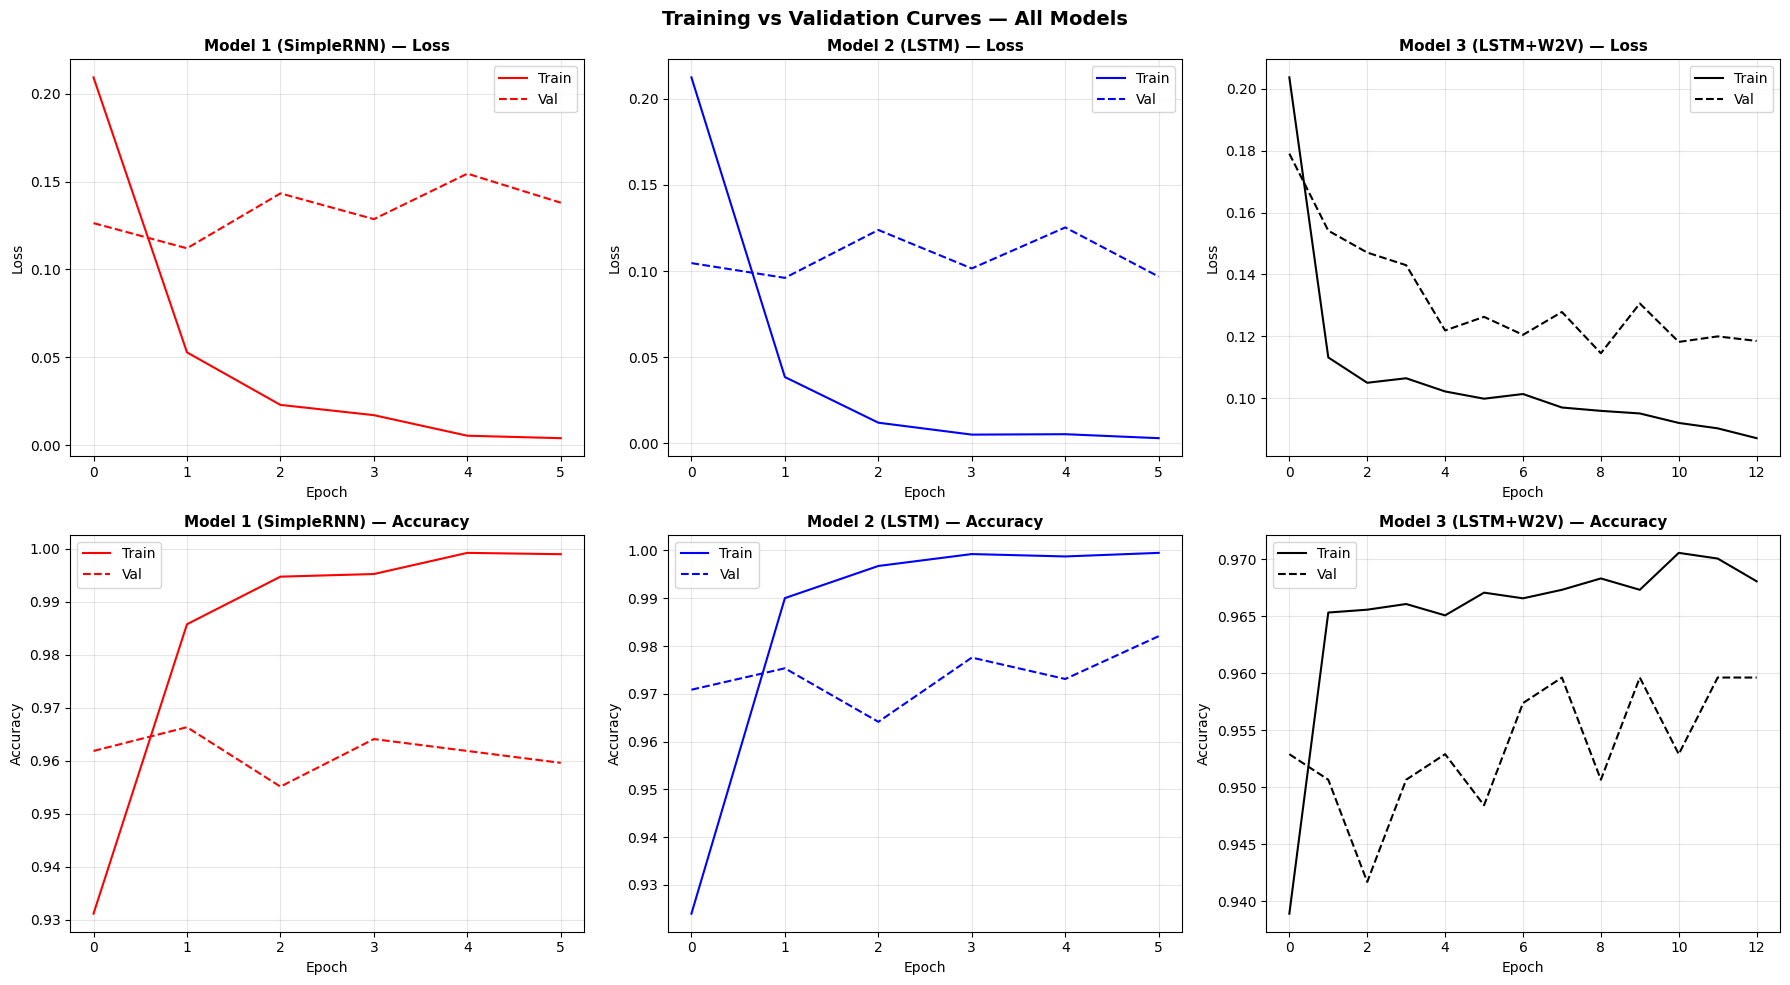

In [44]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
colors = ['red', 'blue', 'black']
model_labels = ['Model 1 (SimpleRNN)', 'Model 2 (LSTM)', 'Model 3 (LSTM+W2V)']

for col_i, (name, hist) in enumerate(all_histories.items()):
    c = colors[col_i]
    label = model_labels[col_i]

    # Loss
    axes[0, col_i].plot(hist.history['loss'],     color=c, ls='-',  label='Train')
    axes[0, col_i].plot(hist.history['val_loss'], color=c, ls='--', label='Val')
    axes[0, col_i].set_title(f'{label} — Loss', fontsize=11, fontweight='bold')
    axes[0, col_i].set_xlabel('Epoch')
    axes[0, col_i].set_ylabel('Loss')
    axes[0, col_i].legend()
    axes[0, col_i].grid(True, alpha=0.3)

    # Accuracy
    axes[1, col_i].plot(hist.history['accuracy'],     color=c, ls='-',  label='Train')
    axes[1, col_i].plot(hist.history['val_accuracy'], color=c, ls='--', label='Val')
    axes[1, col_i].set_title(f'{label} — Accuracy', fontsize=11, fontweight='bold')
    axes[1, col_i].set_xlabel('Epoch')
    axes[1, col_i].set_ylabel('Accuracy')
    axes[1, col_i].legend()
    axes[1, col_i].grid(True, alpha=0.3)

plt.suptitle('Training vs Validation Curves — All Models', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('training_curves.png', dpi=150)
plt.show()

12. Model Evaluation


  Model1 SimpleRNN
  Accuracy  : 97.94%
  Precision : 0.9701
  Recall    : 0.8725
  F1-Score  : 0.9187

              precision    recall  f1-score   support

         Ham       0.98      1.00      0.99       966
        Spam       0.97      0.87      0.92       149

    accuracy                           0.98      1115
   macro avg       0.98      0.93      0.95      1115
weighted avg       0.98      0.98      0.98      1115



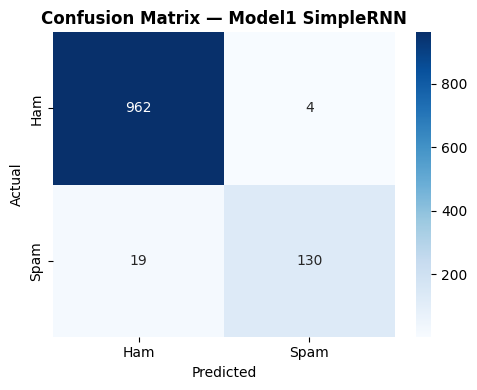


  Model2 LSTM
  Accuracy  : 98.21%
  Precision : 0.9574
  Recall    : 0.9060
  F1-Score  : 0.9310

              precision    recall  f1-score   support

         Ham       0.99      0.99      0.99       966
        Spam       0.96      0.91      0.93       149

    accuracy                           0.98      1115
   macro avg       0.97      0.95      0.96      1115
weighted avg       0.98      0.98      0.98      1115



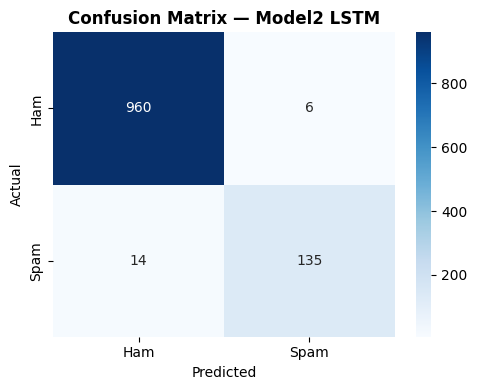


  Model3 LSTM+W2V
  Accuracy  : 97.13%
  Precision : 0.9398
  Recall    : 0.8389
  F1-Score  : 0.8865

              precision    recall  f1-score   support

         Ham       0.98      0.99      0.98       966
        Spam       0.94      0.84      0.89       149

    accuracy                           0.97      1115
   macro avg       0.96      0.92      0.94      1115
weighted avg       0.97      0.97      0.97      1115



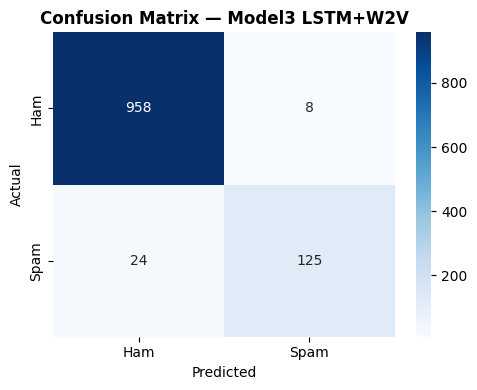

In [45]:
def evaluate_model(model, X, y, name):
    y_prob = model.predict(X, verbose=0).flatten()
    y_pred = (y_prob >= 0.5).astype(int)

    acc  = accuracy_score(y, y_pred)
    prec = precision_score(y, y_pred, zero_division=0)
    rec  = recall_score(y, y_pred, zero_division=0)
    f1   = f1_score(y, y_pred, zero_division=0)

    print(f'\n{"="*55}')
    print(f'  {name}')
    print(f'{"="*55}')
    print(f'  Accuracy  : {acc*100:.2f}%')
    print(f'  Precision : {prec:.4f}')
    print(f'  Recall    : {rec:.4f}')
    print(f'  F1-Score  : {f1:.4f}')
    print()
    print(classification_report(y, y_pred, target_names=['Ham', 'Spam']))

    # Confusion matrix
    cm = confusion_matrix(y, y_pred)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Ham', 'Spam'], yticklabels=['Ham', 'Spam'])
    plt.title(f'Confusion Matrix — {name}', fontweight='bold')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.tight_layout()
    plt.savefig(f'cm_{name.replace(" ","_")}.png', dpi=150)
    plt.show()

    return {'Accuracy': acc, 'Precision': prec, 'Recall': rec, 'F1': f1}

m1_metrics = evaluate_model(model1, X_test_pad, y_test, 'Model1 SimpleRNN')
m2_metrics = evaluate_model(model2, X_test_pad, y_test, 'Model2 LSTM')
m3_metrics = evaluate_model(model3, X_test_pad, y_test, 'Model3 LSTM+W2V')


===== Model Comparison Summary =====
    Model  Accuracy (%)  Precision  Recall  F1-Score  Train Time (s)
SimpleRNN         97.94     0.9701  0.8725    0.9187            20.9
     LSTM         98.21     0.9574  0.9060    0.9310            70.9
 LSTM+W2V         97.13     0.9398  0.8389    0.8865           140.9


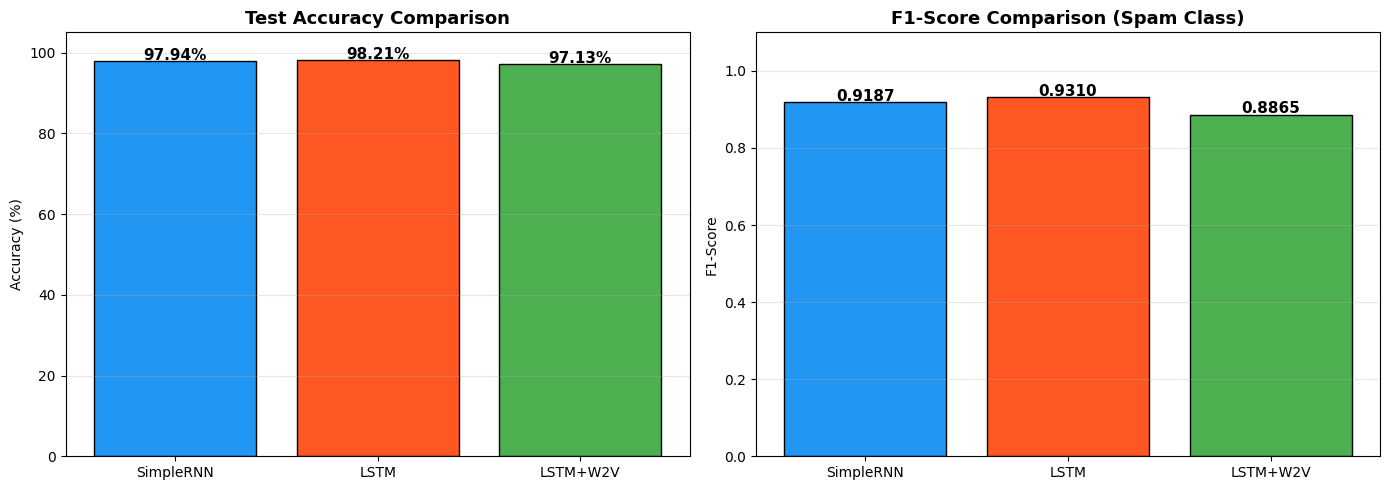

In [46]:
# comparison bar chart
import pandas as pd

results_df = pd.DataFrame({
    'Model':         ['SimpleRNN', 'LSTM', 'LSTM+W2V'],
    'Accuracy (%)':  [round(m['Accuracy']*100, 2) for m in [m1_metrics, m2_metrics, m3_metrics]],
    'Precision':     [round(m['Precision'], 4)    for m in [m1_metrics, m2_metrics, m3_metrics]],
    'Recall':        [round(m['Recall'], 4)        for m in [m1_metrics, m2_metrics, m3_metrics]],
    'F1-Score':      [round(m['F1'], 4)            for m in [m1_metrics, m2_metrics, m3_metrics]],
    'Train Time (s)':[round(all_times[k], 1)       for k in all_times],
})

print('\n===== Model Comparison Summary =====')
print(results_df.to_string(index=False))

# Bar chart
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors = ['#2196F3', '#FF5722', '#4CAF50']

bars = axes[0].bar(results_df['Model'], results_df['Accuracy (%)'],
                   color=colors, edgecolor='black')
for bar, val in zip(bars, results_df['Accuracy (%)']):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
                 f'{val:.2f}%', ha='center', fontsize=11, fontweight='bold')
axes[0].set_title('Test Accuracy Comparison', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Accuracy (%)')
axes[0].set_ylim(0, 105)
axes[0].grid(axis='y', alpha=0.3)

bars2 = axes[1].bar(results_df['Model'], results_df['F1-Score'],
                    color=colors, edgecolor='black')
for bar, val in zip(bars2, results_df['F1-Score']):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
                 f'{val:.4f}', ha='center', fontsize=11, fontweight='bold')
axes[1].set_title('F1-Score Comparison (Spam Class)', fontsize=13, fontweight='bold')
axes[1].set_ylabel('F1-Score')
axes[1].set_ylim(0, 1.1)
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150)
plt.show()

13. Error Analysis

In [48]:
# analysis using Model 3 predictions
y_prob3 = model3.predict(X_test_pad, verbose=0).flatten()
y_pred3 = (y_prob3 >= 0.5).astype(int)

df_err = pd.DataFrame({
    'original_text': X_test,
    'cleaned_text':  [clean_text(t) for t in X_test],
    'true_label':    ['spam' if v == 1 else 'ham' for v in y_test],
    'pred_label':    ['spam' if v == 1 else 'ham' for v in y_pred3],
    'confidence':     np.where(y_pred3 == 1, y_prob3, 1 - y_prob3),
})
df_err['correct'] = df_err['true_label'] == df_err['pred_label']
errors = df_err[~df_err['correct']].sort_values('confidence', ascending=False)

print(f'Total misclassified : {len(errors)} out of {len(df_err)}')
print(f'False Positives (ham predicted as spam): {len(errors[errors["pred_label"]=="spam"])}')
print(f'False Negatives (spam predicted as ham): {len(errors[errors["pred_label"]=="ham"])}')

# Show 3 misclassified examples
print('  MISCLASSIFIED examples — Model 3 (LSTM + W2V)')

fp_ex = errors[errors['pred_label'] == 'spam'].head(2)
fn_ex = errors[errors['pred_label'] == 'ham'].head(1)

for i, (_, row) in enumerate(pd.concat([fp_ex, fn_ex]).iterrows(), 1):
    is_fp = row['pred_label'] == 'spam' and row['true_label'] == 'ham'
    err_type = 'FALSE POSITIVE (Ham predicted as Spam)' if is_fp \
               else 'FALSE NEGATIVE (Spam predicted as Ham)'
    print(f'\nExample {i}: {err_type}')
    print(f'  Original : {row["original_text"][:100]}')
    print(f'  Cleaned  : {row["cleaned_text"][:100]}')
    print(f'  Confidence: {row["confidence"]:.4f}')

print('\nPossible reasons for errors:')
print('  1. FN - ham messages with promotional language similar to spam.')
print('  2. FN - spam messages using uncommon words not in W2V vocabulary.')
print('  3. Short messages lose context after stopword removal.')
print('\nPotential improvements:')
print('  1. Use pre-trained GloVe or FastText embeddings for better coverage.')
print('  2. Use Bidirectional LSTM to capture context from both directions.')
print('  3. Apply class weighting to handle class imbalance.')

Total misclassified : 32 out of 1115
False Positives (ham predicted as spam): 8
False Negatives (spam predicted as ham): 24
  MISCLASSIFIED examples — Model 3 (LSTM + W2V)

Example 1: FALSE POSITIVE (Ham predicted as Spam)
  Original : sent jd customer service cum account executive ur mail id detail contact u
  Cleaned  : sent jd customer service cum account executive ur mail id detail contact
  Confidence: 0.9450

Example 2: FALSE POSITIVE (Ham predicted as Spam)
  Original : fighting world easy either win lose bt fightng close dificult lose lose win still lose
  Cleaned  : fighting world easy either win lose bt fightng close dificult lose lose win still lose
  Confidence: 0.7966

Example 3: FALSE NEGATIVE (Spam predicted as Ham)
  Original : realize year well thousand old lady running around tattoo
  Cleaned  : realize year well thousand old lady running around tattoo
  Confidence: 0.9957

Possible reasons for errors:
  1. FN - ham messages with promotional language similar to spam.


14. Real-Time Prediction GUI (Gradio)

A simple GUI using Gradio allows users to input any SMS message and get a real-time ham/spam prediction.

In [51]:

import gradio as gr

model_map = {
    'Model 1 - SimpleRNN': model1,
    'Model 2 - LSTM':      model2,
    'Model 3 - LSTM+W2V':  model3,
}

def predict_sms(message, model_choice):
    if not message.strip():
        return 'Please enter a message.', '', ''
    cleaned = clean_text(message)
    seq    = tokenizer.texts_to_sequences([cleaned])
    padded = pad_sequences(seq, maxlen=MAX_LEN, padding='post', truncating='post')
    m      = model_map[model_choice]
    prob   = float(m.predict(padded, verbose=0).flatten()[0])
    label  = 'SPAM' if prob >= 0.5 else 'HAM'
    confidence = prob if prob >= 0.5 else 1 - prob
    return label, f'{confidence*100:.1f}%', cleaned

demo = gr.Interface(
    fn=predict_sms,
    inputs=[
        gr.Textbox(label='Enter SMS Message', placeholder='Type your SMS here...', lines=3),
        gr.Dropdown(list(model_map.keys()), label='Select Model', value='Model 3 - LSTM+W2V')
    ],
    outputs=[
        gr.Textbox(label='Prediction (HAM / SPAM)'),
        gr.Textbox(label='Confidence'),
        gr.Textbox(label='Cleaned Text')
    ],
    title='SMS Spam Detector',
    description='Enter an SMS message to classify it as Ham or Spam using RNN/LSTM models.',
    examples=[
        ['Congratulations! You have won a free iPhone. Click here to claim now!', 'Model 3 - LSTM+W2V'],
        ['Hey, are we still meeting for lunch tomorrow?', 'Model 2 - LSTM'],
        ['URGENT: Your account has been compromised. Call 08001234567 immediately.', 'Model 1 - SimpleRNN'],
    ]
)

demo.launch(share=False)

* Running on local URL:  http://127.0.0.1:7860
* To create a public link, set `share=True` in `launch()`.


Created dataset file at: .gradio\flagged\dataset1.csv
